# 1. Load the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('claims.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'claims.csv' not found.")

Dataset loaded successfully.


# 2. Basic Data Inspection

In [3]:
print("\n--- Data Overview ---")
print(df.head())
print(df.info())


--- Data Overview ---
   claim_id  patient_id  provider_id  claim_date  claim_amount    status
0       1.0     23406.0       4385.0  2024-01-06       27537.0  Rejected
1       2.0     21811.0       4979.0  2024-01-27       40137.0  Approved
2       3.0     13518.0        242.0  2024-04-03       20860.0  Approved
3       4.0      6268.0       3037.0  2023-11-03        4999.0  Rejected
4       5.0      9363.0       1543.0  2023-08-19       39084.0  Approved
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   claim_id      200000 non-null  float64
 1   patient_id    200000 non-null  float64
 2   provider_id   200000 non-null  float64
 3   claim_date    200000 non-null  object 
 4   claim_amount  200000 non-null  float64
 5   status        200000 non-null  object 
dtypes: float64(4), object(2)
memory usage: 9.2+ MB
None


# 3. Statistical Analysis & Z-Score Calculation

In [4]:
mean_val = df['claim_amount'].mean()
std_val = df['claim_amount'].std()

print(f"\nMean Claim Amount: ${mean_val:,.2f}")
print(f"Standard Deviation: ${std_val:,.2f}")

df['z_score'] = (df['claim_amount'] - mean_val) / std_val


Mean Claim Amount: $25,793.56
Standard Deviation: $16,921.43


# 4. Identifying Anomalies

In [5]:
threshold = 3
df['is_anomaly'] = df['z_score'] > threshold

anomalies = df[df['is_anomaly']].copy()

print(f"\nTotal Transactions: {len(df)}")
print(f"Number of Anomalies Found: {len(anomalies)}")
print(f"Percentage of Anomalies: {(len(anomalies)/len(df))*100:.2f}%")


Total Transactions: 200000
Number of Anomalies Found: 1167
Percentage of Anomalies: 0.58%


# 5. Visualization


Visualization saved as 'anomaly_plot.png'


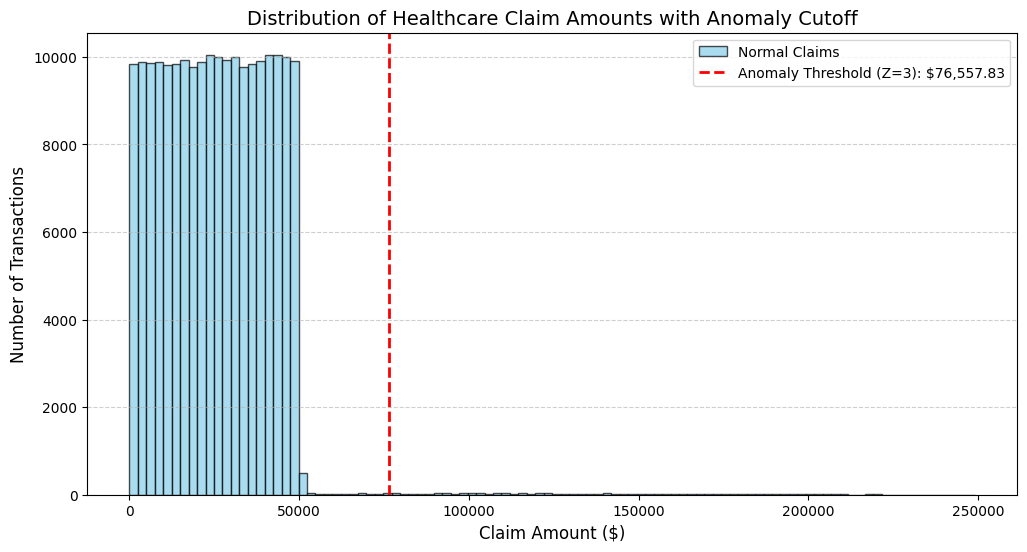

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(df['claim_amount'], bins=100, color='skyblue', edgecolor='black', alpha=0.7, label='Normal Claims')

cutoff_value = mean_val + (threshold * std_val)
plt.axvline(cutoff_value, color='red', linestyle='dashed', linewidth=2, label=f'Anomaly Threshold (Z=3): ${cutoff_value:,.2f}')

plt.title('Distribution of Healthcare Claim Amounts with Anomaly Cutoff', fontsize=14)
plt.xlabel('Claim Amount ($)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig('anomaly_plot.png')
print("\nVisualization saved as 'anomaly_plot.png'")

Scatter plot saved as 'healthcare_scatter_plot.png'


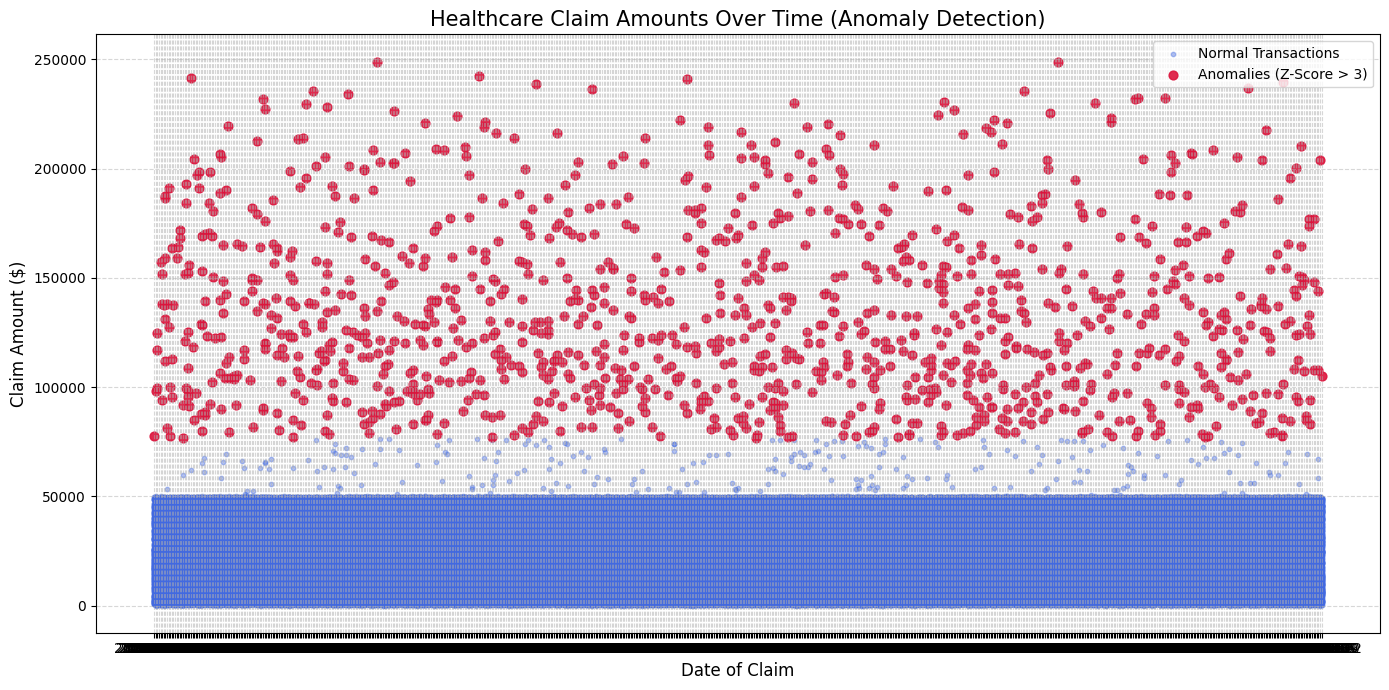

In [9]:
normal = df[df['is_anomaly'] == False]
anomalies = df[df['is_anomaly'] == True]

plt.figure(figsize=(14, 7))

plt.scatter(normal['claim_date'], normal['claim_amount'], 
            alpha=0.4, s=10, color='royalblue', label='Normal Transactions')

plt.scatter(anomalies['claim_date'], anomalies['claim_amount'], 
            alpha=0.9, s=40, color='crimson', label='Anomalies (Z-Score > 3)')

plt.title('Healthcare Claim Amounts Over Time (Anomaly Detection)', fontsize=15)
plt.xlabel('Date of Claim', fontsize=12)
plt.ylabel('Claim Amount ($)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('healthcare_scatter_plot.png')
print("Scatter plot saved as 'healthcare_scatter_plot.png'")

# 6. Exporting Results

In [ ]:
df.to_csv('claims_with_analysis.csv', index=False)

anomalies.to_csv('detected_fraud_alerts.csv', index=False)

print("Results exported to 'claims_with_analysis.csv' and 'detected_fraud_alerts.csv'")

Results exported to 'claims_with_analysis.csv' and 'detected_fraud_alerts.csv'


# 7. Display Top Anomalies

In [8]:
print("\n--- Top 10 Suspected Transactions (Highest Z-Scores) ---")
print(anomalies.sort_values(by='z_score', ascending=False).head(10))


--- Top 10 Suspected Transactions (Highest Z-Scores) ---
        claim_id  patient_id  provider_id  claim_date   claim_amount  \
14724    14725.0     46865.0        799.0  2024-05-25  248984.447236   
44496    44497.0     47090.0       3986.0  2024-05-31  248862.683592   
24023    24024.0     10151.0       4899.0  2024-06-18  242354.693769   
165881  165882.0     12523.0       3697.0  2023-08-28  241561.877672   
71357    71358.0      6486.0       2945.0  2023-10-24  241162.642113   
10610    10611.0     11196.0        837.0  2024-10-14  239737.405058   
8695      8696.0     24498.0       2507.0  2024-07-12  238507.175598   
161796  161797.0     24488.0       3627.0  2024-04-25  236786.449280   
113607  113608.0     36047.0       1134.0  2024-11-14  236544.432149   
2845      2846.0     34890.0       1918.0  2023-11-08  235390.902899   

          status    z_score  is_anomaly  
14724   Approved  13.189840        True  
44496   Approved  13.182644        True  
24023   Approved  12.79